# Ridge 回归 —— L2 正则化惩罚

在基础多元线性回归上引入 **L2 正则化**，观察：
- 系数如何随 λ 增大而收缩
- 正则化对过拟合的抑制效果
- 偏差-方差权衡

核心公式：

$$J(\beta) = \frac{1}{2n}\|X\beta - y\|^2_2 + \lambda\|\beta\|^2_2$$

$$\beta = (X^TX + \lambda I)^{-1}X^Ty$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

## 1. 加载与预处理（同 notebook 1）

In [ ]:
data = fetch_california_housing()
X_raw = data.data
y_raw = data.target
feature_names = data.feature_names
print(f"X: {X_raw.shape}, y: {y_raw.shape}")

In [ ]:
# 标准化
def standardize(X):
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0)
    return (X - mean) / std, mean, std

X_norm, X_mean, X_std = standardize(X_raw)

# 拆分训练/测试集
np.random.seed(42)
n = X_norm.shape[0]
indices = np.random.permutation(n)
split_idx = int(0.8 * n)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y_raw[train_idx], y_raw[test_idx]

# 偏置列
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

print(f"Train: {X_train_b.shape}, Test: {X_test_b.shape}")

## 2. 写 RidgeRegression 类

In [ ]:
class RidgeRegression:
    
    #Ridge（L2 正则化）线性回归，使用闭式解实现。

    

    def __init__(self, lambda_=1.0):
        self.lambda_ = lambda_
        self.beta = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self._fit_normal(X, y)
        return self

    def _build_penalty_matrix(self, d):
        #构造 对角矩阵，第一个对角元素为 0（不惩罚 intercept）
        I_prime = np.eye(d)
        I_prime[0, 0] = 0
        return I_prime

    def _fit_normal(self, X, y):
        #闭式解: β = (XᵀX + nλI')⁻¹ Xᵀy
        n, d = X.shape
        I_prime = self._build_penalty_matrix(d)
        XtX_reg = X.T @ X + n * self.lambda_ * I_prime
        Xty = X.T @ y
        self.beta = np.linalg.pinv(XtX_reg) @ Xty

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.beta

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y_pred - y) ** 2)

    def rmse(self, X, y):
        return np.sqrt(self.mse(X, y))

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

## 3. 基础回归（λ=0）作为基准

In [ ]:
lr_baseline = RidgeRegression(lambda_=0)
lr_baseline.fit(X_train_b, y_train)

print("=== Baseline (λ=0, 等价于普通线性回归) ===")
print(f"Test MSE : {lr_baseline.mse(X_test_b, y_test):.4f}")
print(f"Test RMSE: {lr_baseline.rmse(X_test_b, y_test):.4f}")
print(f"Test R²  : {lr_baseline.score(X_test_b, y_test):.4f}")

base_coefs = pd.DataFrame({
    'Feature': ['Intercept'] + list(feature_names),
    'Coefficient (λ=0)': lr_baseline.beta
})
base_coefs

## 4. 对比不同 λ 的效果

In [27]:
lambdas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

results = []
coef_history = []

for lam in lambdas:
    ridge = RidgeRegression(lambda_=lam)
    ridge.fit(X_train_b, y_train)
    train_mse = ridge.mse(X_train_b, y_train)
    test_mse  = ridge.mse(X_test_b, y_test)
    test_r2   = ridge.score(X_test_b, y_test)
    results.append({
        'lambda': lam,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'test_r2': test_r2
    })
    coef_history.append(ridge.beta)

results_df = pd.DataFrame(results)
results_df

,lambda,train_mse,test_mse,test_r2
0,0.001,0.517302,0.555181,0.587529
1,0.010,0.519169,0.556676,0.586418
2,0.100,0.565828,0.598211,0.555560
3,0.500,0.693932,0.717837,0.466684
4,1.000,0.801777,0.822480,0.388939
5,5.000,1.113783,1.131600,0.159279
6,10.000,1.205746,1.223516,0.090990
7,50.000,1.300434,1.318401,0.020496
8,100.000,1.313968,1.331982,0.010405


## 5. 可视化：系数收缩（Coefficient Path）

/tmp/ipykernel_30605/2555600641.py:26: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30605/2555600641.py:26: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30605/2555600641.py:26: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30605/2555600641.py:26: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30605/2555600641.py:26: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30605/2555600641.py:26: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yin/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarnin

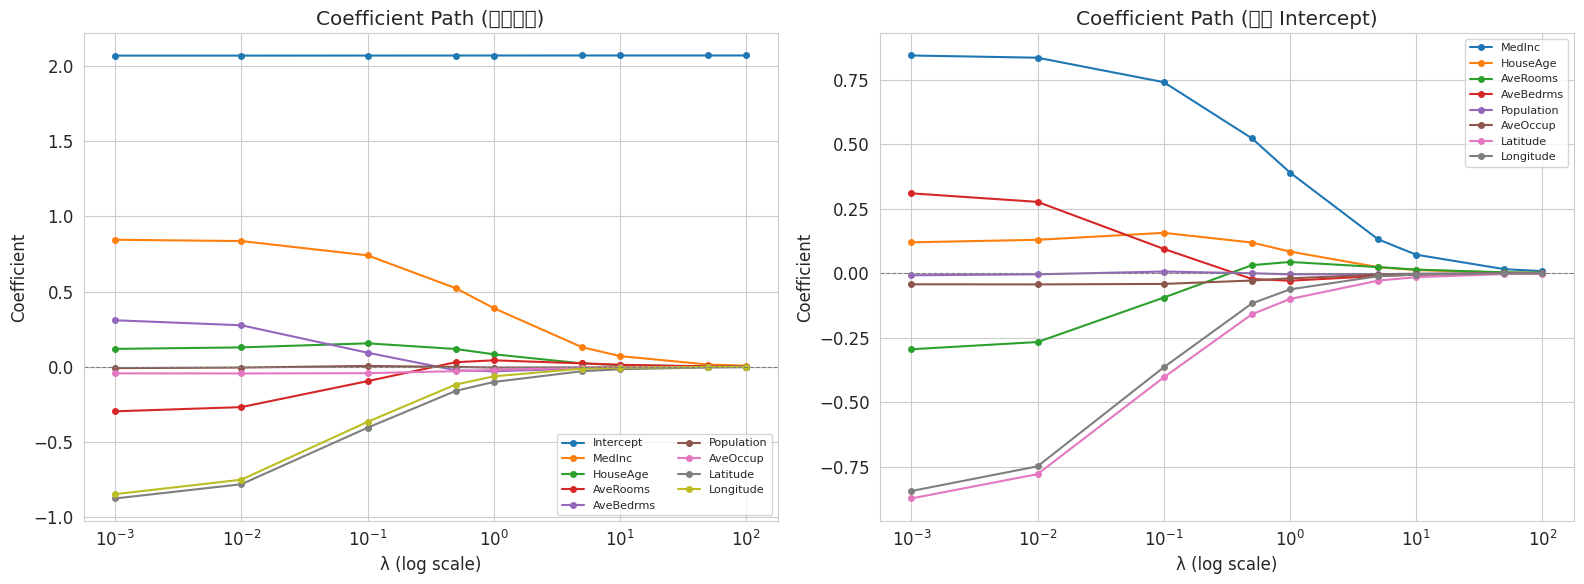

In [28]:
coef_history = np.array(coef_history)  # shape (n_lambdas, n_features+1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：所有系数（含 intercept）
for j in range(coef_history.shape[1]):
    label = 'Intercept' if j == 0 else feature_names[j - 1]
    axes[0].plot(lambdas, coef_history[:, j], 'o-', ms=4, label=label)
axes[0].set_xscale('log')
axes[0].set_xlabel('λ (log scale)')
axes[0].set_ylabel('Coefficient')
axes[0].set_title('Coefficient Path (全部特征)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)

# 右图：去掉 Intercept，看清特征系数收缩
for j in range(1, coef_history.shape[1]):
    axes[1].plot(lambdas, coef_history[:, j], 'o-', ms=4, label=feature_names[j - 1])
axes[1].set_xscale('log')
axes[1].set_xlabel('λ (log scale)')
axes[1].set_ylabel('Coefficient')
axes[1].set_title('Coefficient Path (不含 Intercept)')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)

plt.tight_layout()
plt.show()

## 6. 可视化：训练误差 vs 测试误差（偏差-方差权衡）

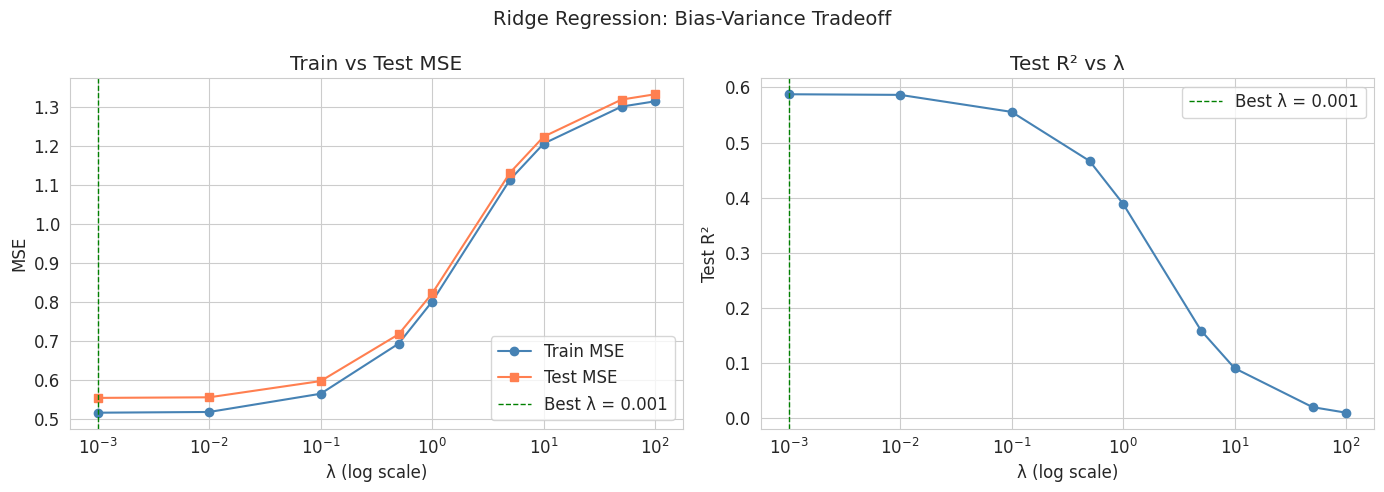

最优 λ = 0.001, 对应 Test MSE = 0.5552


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lambdas, results_df['train_mse'], 'o-', label='Train MSE', color='steelblue')
axes[0].plot(lambdas, results_df['test_mse'], 's-', label='Test MSE', color='coral')
axes[0].set_xscale('log')
axes[0].set_xlabel('λ (log scale)')
axes[0].set_ylabel('MSE')
axes[0].set_title('Train vs Test MSE')
axes[0].legend()

# 标注最优 λ
best_idx = results_df['test_mse'].idxmin()
best_lam = results_df.loc[best_idx, 'lambda']
axes[0].axvline(best_lam, color='green', ls='--', lw=1,
                label=f'Best λ = {best_lam:.3f}')
axes[0].legend()

axes[1].plot(lambdas, results_df['test_r2'], 'o-', color='steelblue')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ (log scale)')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Test R² vs λ')
axes[1].axvline(best_lam, color='green', ls='--', lw=1,
                label=f'Best λ = {best_lam:.3f}')
axes[1].legend()

plt.suptitle('Ridge Regression: Bias-Variance Tradeoff', fontsize=14)
plt.tight_layout()
plt.show()

print(f"最优 λ = {best_lam:.3f}, 对应 Test MSE = {results_df.loc[best_idx, 'test_mse']:.4f}")

## 7. 最优 λ 的系数 vs 基准模型系数

In [30]:
best_ridge = RidgeRegression(lambda_=best_lam)
best_ridge.fit(X_train_b, y_train)

coef_comparison = pd.DataFrame({
    'Feature': ['Intercept'] + list(feature_names),
    'OLS (λ=0)': lr_baseline.beta,
    f'Ridge (λ={best_lam:.3f})': best_ridge.beta
})
coef_comparison['Shrinkage (%)'] = (
    (1 - np.abs(best_ridge.beta) / (np.abs(lr_baseline.beta) + 1e-10)) * 100
).round(1)
coef_comparison

,Feature,OLS (λ=0),Ridge (λ=0.001),Shrinkage (%)
0,Intercept,2.067009,2.067014,-0.0
1,MedInc,0.844985,0.844200,0.1
2,HouseAge,0.118311,0.119611,-1.1
3,AveRooms,-0.298115,-0.295016,1.0
4,AveBedrms,0.313409,0.309585,1.2
5,Population,-0.008633,-0.008151,5.6
6,AveOccup,-0.042989,-0.043067,-0.2
7,Latitude,-0.885903,-0.873670,1.4
8,Longitude,-0.857195,-0.844810,1.4
